In [1]:
!pip install -q -U "diffusers[torch]" transformers accelerate safetensors matplotlib lpips "pandas<3"
!pip install -q -U --force-reinstall "Pillow<12"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 103.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 150.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 122.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 94.3 MB/s eta 0:00:00ta 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 136.5 MB/s

In [2]:
from pathlib import Path
import zipfile
import urllib.request

MOUNT_GOOGLE_DRIVE = True

if MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as exc:
        print("Google Drive mount skipped:", exc)

# Optional online URL for a zip with the target images.
# Leave empty if targets are already available locally or in Drive.
TARGETS_ZIP_URL = ""

CONTENT_DIR = Path("/content")
DRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_PROJECT_DIR = DRIVE_ROOT / "GENAI_TP2"
LOCAL_PROJECT_DIR = CONTENT_DIR / "GENAI_TP2" if CONTENT_DIR.exists() else Path("students")

if DRIVE_ROOT.exists():
    DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs"
elif CONTENT_DIR.exists():
    OUTPUT_DIR = CONTENT_DIR / "tp2_outputs"
else:
    OUTPUT_DIR = Path("students/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

def list_target_images(path):
    path = Path(path)
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path]
    if not path.exists():
        return []
    return sorted(p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)

TARGET_DIR_CANDIDATES = [
    Path("students/tp2-chosen"),
    Path("tp2-chosen"),
    Path("/content/tp2-chosen"),
    Path("/content/tp2_targets"),
    DRIVE_PROJECT_DIR / "tp2-chosen",
    Path("/content/drive/MyDrive/tp2-chosen"),
    Path("/content/drive/MyDrive/tp2_targets"),
]

ZIP_CANDIDATES = [
    Path("students/tp2-chosen.zip"),
    Path("tp2-chosen.zip"),
    Path("/content/tp2-chosen.zip"),
    DRIVE_PROJECT_DIR / "tp2-chosen.zip",
    Path("/content/drive/MyDrive/tp2-chosen.zip"),
]

# Download optional online zip.
if TARGETS_ZIP_URL:
    LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_zip = LOCAL_PROJECT_DIR / "tp2-chosen.zip"
    urllib.request.urlretrieve(TARGETS_ZIP_URL, downloaded_zip)
    ZIP_CANDIDATES.insert(0, downloaded_zip)
    print("Downloaded targets zip to", downloaded_zip)

# Extract first available zip if no folder with images exists yet.
if not any(list_target_images(candidate) for candidate in TARGET_DIR_CANDIDATES):
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = Path("/content/tp2-chosen") if CONTENT_DIR.exists() else Path("tp2-chosen")
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as zf:
                zf.extractall(extract_dir)
            print(f"Extracted {zip_path} -> {extract_dir}")
            break

TARGET_DIR = None
for candidate in TARGET_DIR_CANDIDATES:
    if list_target_images(candidate):
        TARGET_DIR = candidate
        break

if TARGET_DIR is None:
    raise FileNotFoundError(
        "No target images found. Put images in MyDrive/GENAI_TP2/tp2-chosen, "
        "or put tp2-chosen.zip in MyDrive/GENAI_TP2, or set TARGETS_ZIP_URL."
    )

target_images = list_target_images(TARGET_DIR)
print("Target folder:", TARGET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Number of targets:", len(target_images))
target_images


Mounted at /content/drive
Target folder: /content/drive/MyDrive/GENAI_TP2/tp2-chosen
Output folder: /content/drive/MyDrive/GENAI_TP2/outputs
Number of targets: 6


[PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/1159_25.png'),
 PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/1159_29.png'),
 PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/1159_3.png'),
 PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/1159_7.png'),
 PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/7836.png'),
 PosixPath('/content/drive/MyDrive/GENAI_TP2/tp2-chosen/9338.png')]

In [3]:
import csv
import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def seed_from_filename(path, fallback=2026):
    match = re.match(r"^(\d+)", Path(path).stem)
    return int(match.group(1)) if match else fallback


def safe_stem(path):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in Path(path).stem)


def load_image(path):
    return Image.open(path).convert("RGB")


def create_run_dir(base_dir=OUTPUT_DIR, identity="student_run"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = Path(base_dir) / f"{timestamp}_{identity}"
    run_dir.mkdir(parents=True, exist_ok=False)
    return run_dir


def write_csv(path, rows):
    rows = list(rows)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        Path(path).write_text("")
        return
    fieldnames = []
    for row in rows:
        for key in row.keys():
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def show_images(paths, cols=3, title=None):
    paths = list(paths)
    if not paths:
        print("No images to show.")
        return
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    for ax in [ax for row in axes for ax in row]:
        ax.axis("off")
    for ax, path in zip([ax for row in axes for ax in row], paths):
        ax.imshow(load_image(path))
        ax.set_title(Path(path).name)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


for path in target_images:
    print(Path(path).name, "-> seed", seed_from_filename(path))


1159_25.png -> seed 1159
1159_29.png -> seed 1159
1159_3.png -> seed 1159
1159_7.png -> seed 1159
7836.png -> seed 7836
9338.png -> seed 9338


In [4]:
from dataclasses import dataclass
import torch
from diffusers import DiffusionPipeline


@dataclass(frozen=True)
class LCMConfig:
    model_id: str = "SimianLuo/LCM_Dreamshaper_v7"
    seed: int = 2026  # fallback only; target filenames define the real render seed
    num_inference_steps: int = 8
    guidance_scale: float = 8.0
    lcm_origin_steps: int = 50
    width: int = 768
    height: int = 768


config = LCMConfig()


def default_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


device = default_device()
print("Using device:", device)


def load_lcm_pipeline(config):
    dtype = torch.float16 if device == "cuda" else torch.float32
    pipe = DiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        use_safetensors=True,
    )
    if hasattr(pipe, "safety_checker"):
        pipe.safety_checker = None
    pipe.to(device)
    return pipe


pipe = load_lcm_pipeline(config)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [5]:
def render_prompt(prompt, seed, pipe=pipe, config=config):
    generator_device = "cpu" if device == "mps" else device
    generator = torch.Generator(device=generator_device).manual_seed(seed)
    image = pipe(
        prompt=prompt,
        num_inference_steps=config.num_inference_steps,
        guidance_scale=config.guidance_scale,
        lcm_origin_steps=config.lcm_origin_steps,
        width=config.width,
        height=config.height,
        output_type="pil",
        generator=generator,
    ).images[0]
    return image


def render_prompt_for_target(prompt, target_path):
    seed = seed_from_filename(target_path, config.seed)
    return render_prompt(prompt, seed=seed)


def save_generated_image(image, run_dir, target_path, prompt_index=1):
    target_dir = Path(run_dir) / safe_stem(target_path)
    target_dir.mkdir(parents=True, exist_ok=True)
    path = target_dir / f"candidate_{prompt_index:03d}.png"
    image.save(path)
    return path


In [ ]:
import importlib.util

def import_from_drive(module_name):
    path = f"/content/drive/MyDrive/GENAI_TP2/src/{module_name}.py"
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

In [7]:
fitness=import_from_drive("fitness")
clip_model, clip_processor = fitness.load_clip(device)
lpips_fn = fitness.load_lpips(device)

target = load_image(target_images[0])
test1 = fitness.compute_fitness(target, target, clip_model, clip_processor, lpips_fn, device)
print(f"Sanity check (target vs target): fitness={test1['fitness']:.4f} clip={test1['clip']:.4f} lpips={test1['lpips']:.4f} rmse={test1['rmse']:.4f}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 244MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Sanity check (target vs target): fitness=1.0000 clip=1.0000 lpips=0.0000 rmse=0.0000


In [8]:
VLM_PATH = OUTPUT_DIR/"VLM"
VLM_PATH.mkdir(parents=True, exist_ok=True)
candidates_path= VLM_PATH/"vlm_candidates.json"
vlm_module=import_from_drive("vlm")
if candidates_path.exists():
    with open(candidates_path, "r") as f:
        data = json.load(f)
    candidates = data["candidates"]
    print(f"Candidates loaded from drive ({len(candidates)})")
else:
    vlm, vlm_processor = vlm_module.load_vlm()
    candidates = vlm_module.generate_initial_candidates(
        target_path=target_images[0],
        vlm=vlm,
        processor=vlm_processor,
        n_candidates=10,
        temperature=0.9,
    )
    vlm_module.unload_vlm(vlm, vlm_processor)

    with open(candidates_path, "w") as f:
        json.dump({"target": str(target_images[0]), "candidates": candidates}, f, indent=2)
    print(f"Generated and saved candidates to {candidates_path}")

Candidates loaded from drive (10)


In [9]:
target = load_image(target_images[0])
evaluated = []
VLM_IMAGES=VLM_PATH/ "images"
VLM_IMAGES.mkdir(parents=True, exist_ok=True)
for i, prompt in enumerate(candidates, 1):
    print(f"[{i:02d}/{len(candidates)}]")
    generated = render_prompt(prompt, seed=seed_from_filename(target_images[0]), pipe=pipe, config=config)
    metrics = fitness.compute_fitness(generated, target, clip_model, clip_processor, lpips_fn, device)
    evaluated.append({"prompt": prompt, "generated": generated, **metrics})
    print(f"fitness={metrics['fitness']:.4f} clip={metrics['clip']:.4f} lpips={metrics['lpips']:.4f} rmse={metrics['rmse']:.4f}")
    generated.save(VLM_IMAGES/f"generated_{i:03d}.png")



[01/10]


  0%|          | 0/8 [00:00<?, ?it/s]

fitness=0.8205 clip=0.8785 lpips=0.4484 rmse=0.1601
[02/10]


  0%|          | 0/8 [00:00<?, ?it/s]

fitness=0.8378 clip=0.8942 lpips=0.4079 rmse=0.1340
[03/10]


...

fitness=0.8238 clip=0.8935 lpips=0.4830 rmse=0.1713
[09/10]


  0%|          | 0/8 [00:00<?, ?it/s]

fitness=0.8038 clip=0.8670 lpips=0.5108 rmse=0.1759
[10/10]


  0%|          | 0/8 [00:00<?, ?it/s]

fitness=0.7938 clip=0.8397 lpips=0.4733 rmse=0.1584


In [10]:
opro_module = import_from_drive("OPRO")

OPRO_PATH = OUTPUT_DIR / "OPRO"
OPRO_PATH.mkdir(parents=True, exist_ok=True)
OPRO_IMAGES = OPRO_PATH / "images"
OPRO_IMAGES.mkdir(parents=True, exist_ok=True)
OPRO_CHECKPOINTS = OPRO_PATH / "checkpoints"
OPRO_CHECKPOINTS.mkdir(parents=True, exist_ok=True)

checkpoints = sorted(OPRO_CHECKPOINTS.glob("opro_iter_*.json"))

if checkpoints:
    with open(checkpoints[-1], "r") as f:
        population = json.load(f)
    best_fitness = max(c["fitness"] for c in population)
    no_improve_count = 0
    iteration = population[0].get("iteration", 0)
    print(f" Checkpoint carregado — iteration {iteration}, best fitness {best_fitness:.4f}")
else:
    population = [
        {"prompt": c["prompt"], "fitness": c["fitness"],
         "clip": c["clip"], "lpips": c["lpips"], "rmse": c["rmse"]}
        for c in evaluated
    ]
    best_fitness = max(c["fitness"] for c in population)
    no_improve_count = 0
    iteration = 0
    print(f" Starting OPRO from iteration 0 — {len(population)} candidates")

llm, tokenizer = opro_module.load_llm()

 Starting OPRO from iteration 0 — 10 candidates


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]


[Iteration 1]
  [01/5] A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, glowing with a rich, luminous amber hue, garnished with a perfectly sliced orange and a delicate piece of candied orange peel, set on a weather
  [02/5] A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, the liquid glowing with a radiant, sunlit amber hue, garnished with a perfectly sliced orange and a delicate twist of candied orange peel, floating gently
  [03/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed golden hue, resting on a rich, slightly textured walnut wood surface. A perfect slice of orange rests on the rim,
  [04/5] A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, glowing with a rich, luminous golden-orange hue, garnished with a perfect slice of orange and a delicate piece of candied orange peel resting

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8049 | A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, glowing with a rich, luminous amber hue, garnished with a perfectly sliced orange and a delicate piece of candied orange peel, set on a weather


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8060 | A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, the liquid glowing with a radiant, sunlit amber hue, garnished with a perfectly sliced orange and a delicate twist of candied orange peel, floating gently


...

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8110 | A hyper-detailed, cinematic still life of a freshly squeezed orange juice in a clear glass, glowing with a rich, luminous golden-orange hue, garnished with a perfect slice of orange and a delicate piece of candied orange peel resting on the


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8132 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a rich, sunlit golden hue, garnished with a thin slice of orange and a delicate piece of candied orange peel, set on a polished,
 Best: 0.8542 | Mean: 0.8139
  Checkpoint saved: opro_iter_001.json
 No improvement (1/5)


  0%|          | 0/8 [00:00<?, ?it/s]

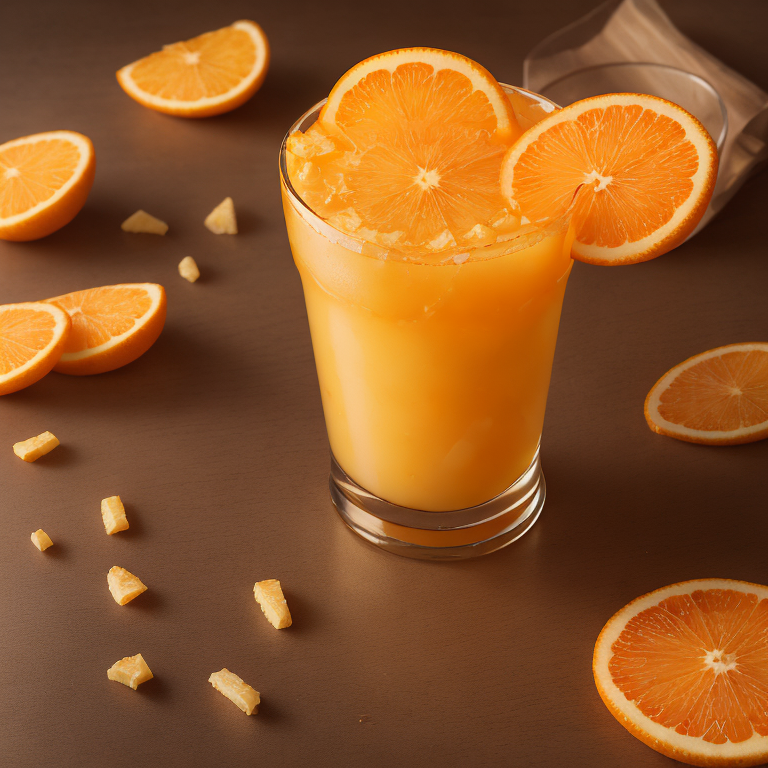


[Iteration 2]
  [01/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sunlit amber hue, garnished with a perfectly thin slice of orange and a delicate twist of candied orange peel suspended in mid-air by
  [02/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sun-drenched golden glow with a subtle iridescent sheen, garnished with a perfectly thin slice of orange and a delicate, textured
  [03/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a luminous, sun-drenched amber glow, garnished with a perfectly crafted thin slice of orange and a delicate, crystalline twist of candied orange
  [04/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sunlit golden amber glow with a subtle, reflective sheen, garnished with a perfectly thin slice of orange and a delicate, intricately


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8066 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sunlit amber hue, garnished with a perfectly thin slice of orange and a delicate twist of candied orange peel suspended in mid-air by


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7996 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sun-drenched golden glow with a subtle iridescent sheen, garnished with a perfectly thin slice of orange and a delicate, textured


...

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8172 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sunlit golden amber glow with a subtle, reflective sheen, garnished with a perfectly thin slice of orange and a delicate, intricately


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8121 | A hyper-realistic, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sunlit amber glow with a subtle shimmer, garnished with a perfectly thin slice of orange and a delicate, translucent piece of candied orange
 Best: 0.8542 | Mean: 0.8124
  Checkpoint saved: opro_iter_002.json
 No improvement (2/5)


  0%|          | 0/8 [00:00<?, ?it/s]

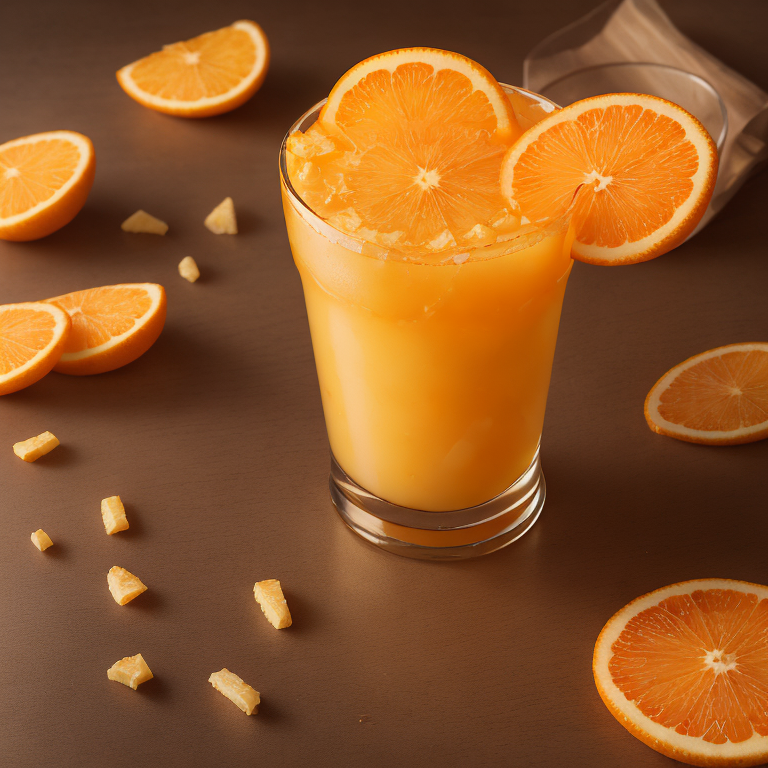


[Iteration 3]
  [01/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a luminous, sun-drenched amber glow with a subtle iridescent shimmer, garnished with a perfectly thin, translucent slice of orange and a delicate
  [02/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a luminous, sun-drenched amber glow with a subtle iridescent sheen, garnished with a perfectly thin slice of orange, a delicate twist
  [03/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed amber luminescence, garnished with a perfectly thin, jewel-toned slice of orange and a suspended, irides
  [04/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed amber hue, garnished with a perfectly thin, glossy slice of orange and a delicate, crystalline twist of candied
  [05/5] A hyper-detailed,

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7998 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a luminous, sun-drenched amber glow with a subtle iridescent shimmer, garnished with a perfectly thin, translucent slice of orange and a delicate


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8091 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a luminous, sun-drenched amber glow with a subtle iridescent sheen, garnished with a perfectly thin slice of orange, a delicate twist


...

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7936 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed amber hue, garnished with a perfectly thin, glossy slice of orange and a delicate, crystalline twist of candied


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7900 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sun-kissed golden amber glow with a delicate iridescent sheen, garnished with a perfectly thin, dewy slice of orange
 Best: 0.8542 | Mean: 0.8137
  Checkpoint saved: opro_iter_003.json
 No improvement (3/5)


  0%|          | 0/8 [00:00<?, ?it/s]

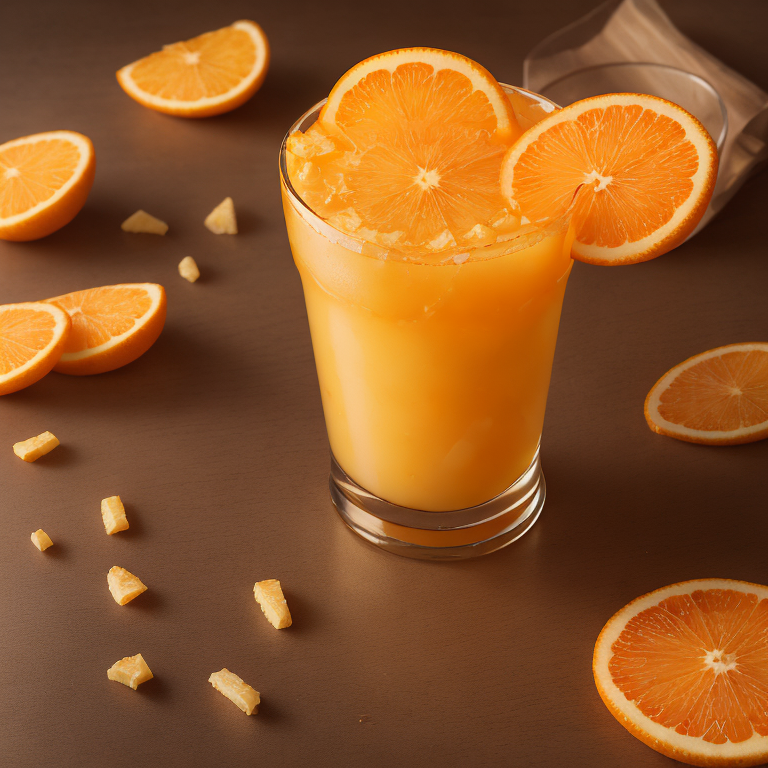


[Iteration 4]
  [01/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed golden amber hue that pulses with a soft, iridescent undertone, garnished with a perfectly thin, translucent slice
  [02/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a radiant, sun-kissed amber glow with a delicate iridescent ripple effect, garnished with a perfectly thin, translucent slice of orange and a
  [03/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed amber light that pulses with subtle iridescence, garnished with a perfectly thin, translucent orange slice and a delicate
  [04/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a rich, sun-kissed golden amber glow with a dynamic, crystalline iridescence that shifts subtly with the light, garnished with a
  [05/5] A hype

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8143 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed golden amber hue that pulses with a soft, iridescent undertone, garnished with a perfectly thin, translucent slice


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8101 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a radiant, sun-kissed amber glow with a delicate iridescent ripple effect, garnished with a perfectly thin, translucent slice of orange and a


...

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7811 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a rich, sun-kissed golden amber glow with a dynamic, crystalline iridescence that shifts subtly with the light, garnished with a


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7630 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a molten, sunlit amber glow with a mesmerizing iridescent ripple effect, garnished with a perfectly thin, translucent slice of orange, a
 Best: 0.8542 | Mean: 0.8149
  Checkpoint saved: opro_iter_004.json
 No improvement (4/5)


  0%|          | 0/8 [00:00<?, ?it/s]

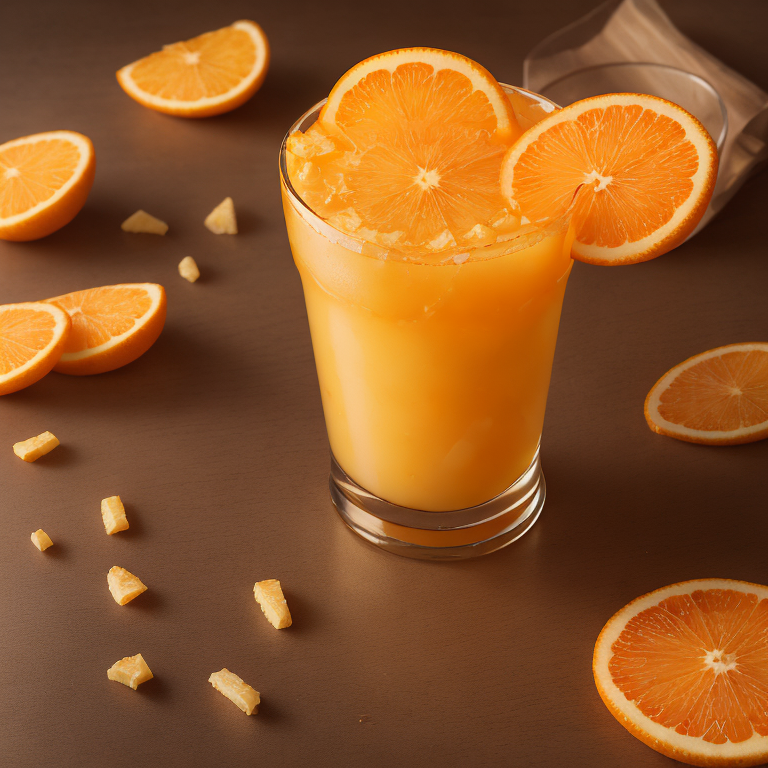


[Iteration 5]
  [01/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a molten, sun-kissed amber glow with a dynamic iridescent ripple effect that seems to breathe and shift in real time, garnished with
  [02/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a rich, sun-kissed golden amber hue that shimmers with delicate iridescent ripples, garnished with a perfectly thin, translucent slice of
  [03/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a warm, sun-drenched golden amber glow with a subtle, dynamic iridescent ripple effect that mimics sunlight dancing on the surface, garnished with
  [04/5] A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed golden amber hue that shifts subtly with light, emanating a soft, iridescent ripple effect like liquid sunlight, garn
  [05/5] 

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7733 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a molten, sun-kissed amber glow with a dynamic iridescent ripple effect that seems to breathe and shift in real time, garnished with


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8084 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a rich, sun-kissed golden amber hue that shimmers with delicate iridescent ripples, garnished with a perfectly thin, translucent slice of


...

  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.8015 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, glowing with a radiant, sun-kissed golden amber hue that shifts subtly with light, emanating a soft, iridescent ripple effect like liquid sunlight, garn


  0%|          | 0/8 [00:00<?, ?it/s]

  fitness=0.7964 | A hyper-detailed, cinematic still life of a freshly squeezed glass of orange juice, radiating a molten, sun-drenched amber glow with a subtle, rippling iridescence that mimics sunlight filtering through citrus leaves, garnished with
 Best: 0.8542 | Mean: 0.8154
  Checkpoint saved: opro_iter_005.json
 No improvement (5/5)


  0%|          | 0/8 [00:00<?, ?it/s]

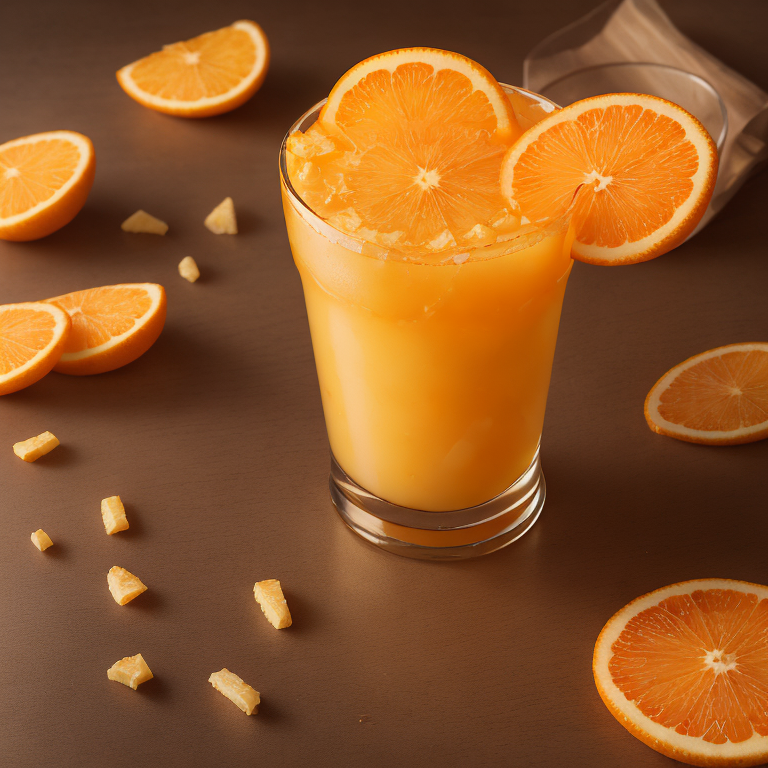

 5 iterations without improvement.

 OPRO terminates — best fitness: 0.8542
 A vibrant orange juice drink in a clear glass, filled with a smooth, creamy yellow liquid, garnished with fresh orange slices and a piece of citrus peel. The glass sits on a dark brown wooden surface, with scattered orange peel chunks around it.


In [11]:
while True:
    iteration += 1
    print(f"\n[Iteration {iteration}]")

    new_prompts = opro_module.generate_initial_candidates(llm, tokenizer, population, n_candidates=5)

    new_candidates = []
    for prompt in new_prompts:
        generated = render_prompt(prompt, seed=seed_from_filename(target_images[0]), pipe=pipe, config=config)
        metrics = fitness.compute_fitness(generated, target, clip_model, clip_processor, lpips_fn, device)
        new_candidates.append({
            "prompt": prompt,
            "fitness": metrics["fitness"],
            "clip": metrics["clip"],
            "lpips": metrics["lpips"],
            "rmse": metrics["rmse"],
            "iteration": iteration,
        })
        print(f"  fitness={metrics['fitness']:.4f} | {prompt}")

    population = sorted(population + new_candidates, key=lambda x: x["fitness"], reverse=True)[:20]

    current_best = population[0]["fitness"]
    avg_fitness = sum(c["fitness"] for c in population) / len(population)
    print(f" Best: {current_best:.4f} | Mean: {avg_fitness:.4f}")

    checkpoint_path = OPRO_CHECKPOINTS / f"opro_iter_{iteration:03d}.json"
    with open(checkpoint_path, "w") as f:
        json.dump(population, f, indent=2)
    print(f"  Checkpoint saved: {checkpoint_path.name}")

    if current_best > best_fitness:
        best_fitness = current_best
        no_improve_count = 0
    else:
        no_improve_count += 1
        print(f" No improvement ({no_improve_count}/5)")

    best_image = render_prompt(population[0]["prompt"], seed=seed_from_filename(target_images[0]), pipe=pipe, config=config)
    best_image.save(OPRO_IMAGES / f"best_iter_{iteration:03d}.png")
    display(best_image)

    if no_improve_count >= 5:
        print(f" 5 iterations without improvement.")
        break

print(f"\n OPRO terminates — best fitness: {population[0]['fitness']:.4f}")
print(f" {population[0]['prompt'] }")